# Parte 1: Carregamento e Inspeção dos Dados:

Carregamento e Inspeção:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("tips.csv")
df.head(10)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


Estrutura dos Dados:

In [10]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  418 non-null    float64
 1   tip         418 non-null    float64
 2   sex         418 non-null    str    
 3   smoker      418 non-null    str    
 4   day         418 non-null    str    
 5   time        418 non-null    str    
 6   size        418 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 23.0 KB


,total_bill,tip,size
count,418.000000,418.000000,418.000000
mean,19.637871,2.997775,2.523923
std,8.515342,1.335773,0.859787
min,5.750000,1.000000,1.000000
25%,13.160000,2.000000,2.000000
50%,17.550000,3.000000,2.000000
75%,24.047500,3.550000,3.000000
max,50.810000,10.000000,6.000000


## Pergunta Analítica (Parte 1):

Ao analisar a saída do `.info()` julgo que os dados parecem adequados para começar uma análise, mas poderia estar melhor.
Estão bons, pois todas as linhas têm valores não nulos e parecem bem escritos (sem erros ortográficos ou valores semanticamente semelhantes, como "janta" e "jantar"). No entanto, alguns dados, como `sex` e `smoker` poderiam estar cadastrados categoricamente ao invés de estarem cadastrados como uma `string`.

Analisando a saída do `.describe()` para o atributo `total_bill` temos a média como 19,6 e a mediana 50% como 17,5. Como a média e mediana 50% são valores próximos sugere-me que grande parte das contas nesse estabelecimento sejam aproximadamente do mesmo valor.

Como não conheço a origem dos dados, o nome de algumas variáveis soa-me ambíguo no seu significado. `sex`, por exemplo, entendo que se refere ao sexo de alguém, mas não sei se é do cliente ou do atendente.

# Parte 2: Análise Univariada e Criação de Variável

Criação de nova coluna de percentual da gorjeta:

In [75]:
df['tip_pct'] = df['tip'] / df['total_bill']
df.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,0.146808


Verificar a frequência de clientes fumantes e não fumantes:

In [76]:
print(df['smoker'].value_counts())

smoker
No     260
Yes    158
Name: count, dtype: int64


Gráfico de contagem (countplot) para a variável `day`:

<Axes: xlabel='count', ylabel='day'>

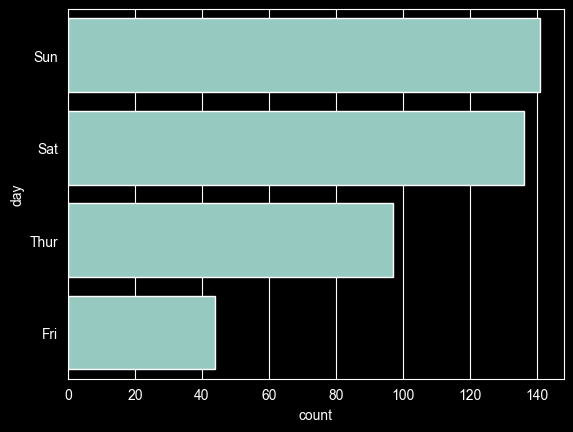

In [22]:
sns.countplot(df['day'])

Histograma com curva de densidade para variável `total_bill`:

<Axes: xlabel='total_bill', ylabel='Count'>

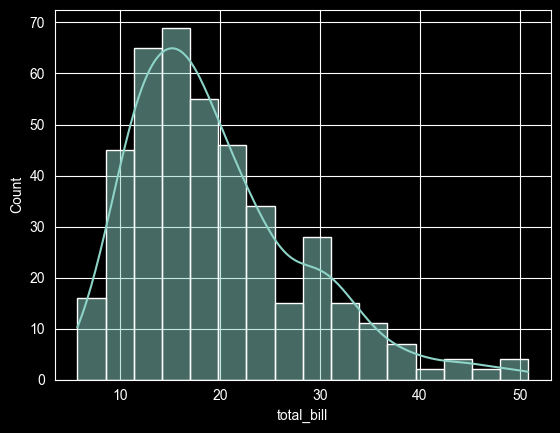

In [25]:
sns.histplot(df['total_bill'],  kde=True)

Dataframe ordenado pelos 10 maiores valores de `total_bill`:

In [28]:
df.nlargest(10, 'total_bill')

,total_bill,tip,sex,smoker,day,time,size,tip_pct
152,50.81,10.0,Male,Yes,Sat,Dinner,3,0.196812
342,50.81,10.0,Male,Yes,Sat,Dinner,3,0.196812
56,48.17,5.0,Male,No,Sun,Dinner,6,0.103799
246,48.17,5.0,Male,No,Sun,Dinner,6,0.103799
170,45.35,3.5,Male,Yes,Sun,Dinner,3,0.077178
360,45.35,3.5,Male,Yes,Sun,Dinner,3,0.077178
141,44.30,2.5,Female,Yes,Sat,Dinner,3,0.056433
331,44.30,2.5,Female,Yes,Sat,Dinner,3,0.056433
118,43.11,5.0,Female,Yes,Thur,Lunch,4,0.115982
308,43.11,5.0,Female,Yes,Thur,Lunch,4,0.115982


In [79]:
percent_df = df[df['tip_pct']>0.30]
display(percent_df)


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_pct
154,7.25,5.15,Male,Yes,Sun,Dinner,2,0.710345,0.710345
344,7.25,5.15,Male,Yes,Sun,Dinner,2,0.710345,0.710345


## Perguntas Analíticas (Parte 2):
1: Os clientes que gastaram mais não foram os clientes que deixaram as maiores gorjetas proporcionais.

2: No dataset há duas mesas consideradas atípicas (que deram gorjetas acima de 30% do valor da conta).
Observando as informações das linhas de outliers podemos observar que todos os dados são os mesmos. É possível inferir que possa ter sido o mesmo cliente, pois os clientes são fumantes, do mesmo sexo e foram jantar num domingo, pode ser uma coincidência e pode ser uma linha repetida do dataset, pois acho difícil repetir um valor quebrado (12,40) no total gasto pela pessoa (somando total da conta com a gorjeta).


# Parte 3: Análise Bivariada (Relações):

Gráfico de dispersão de `total_bill` por `tip`:

<Axes: xlabel='total_bill', ylabel='tip'>

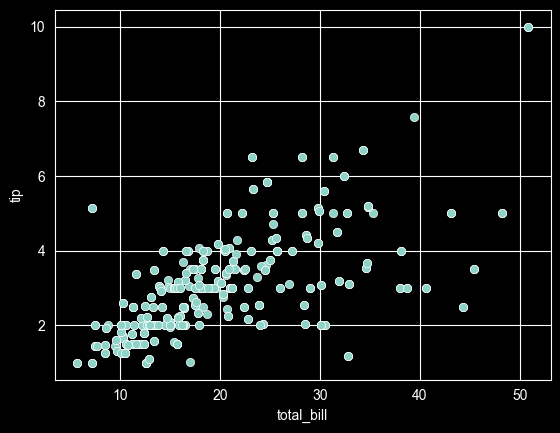

In [80]:
sns.scatterplot(df, y='tip', x='total_bill')

Gráfico de barras de gorjeta proporcional média por sexo:

<Axes: xlabel='sex', ylabel='tip_pct'>

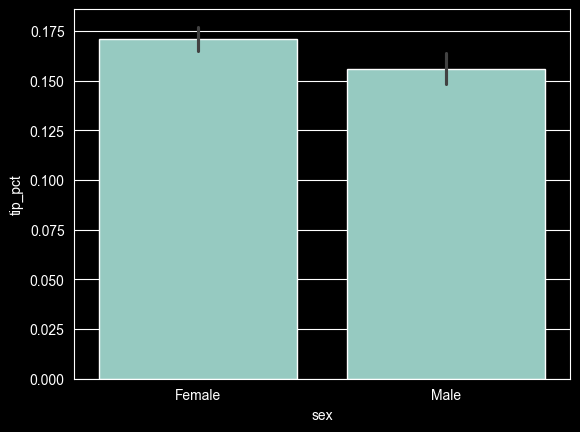

In [86]:
sns.barplot(df, x='sex', y='tip_pct')

Média de gorjeta por dia da semana:

In [94]:
df.groupby('day')['tip'].mean()

day
Fri     2.378182
Sat     3.079412
Sun     3.270993
Thur    2.767216
Name: tip, dtype: float64

## Pergunta Analítica (Parte 3):

Analisando o gráfico de dispersão é possível dizer que há uma relação forte entre o valor da conta e o valor absoluto da gorjeta. Pelo que podemos observar analisando os pontos, é possível considerar que a grande maioria das gorjetas são de aproximadamente 20% do valor da conta.

Analisando o grafico de barras podemos inferir que não há grande diferença na proporção de gorjeta deixada entre homens e mulheres. Podemos perceber que a diferença no percentual da gorjeta deixada por cada sexo é de aproximadamente 1%, que é uma diferença pouco significativa.

# Parte 4: Análise Multivariada e Síntese:

Gráfico de dispersão de `total_bill` por `tip` colorido pela variável `smoker`:

<Axes: xlabel='total_bill', ylabel='tip'>

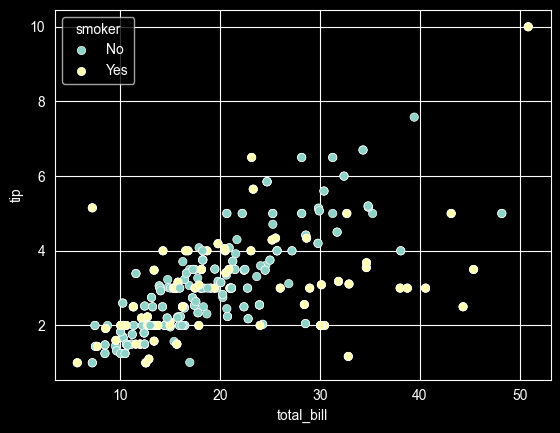

In [96]:
sns.scatterplot(df, y='tip', x='total_bill', hue='smoker')

Gráfico de barras de valor médio da gorjeta absoluta por dia colorido pelo tipo de refeição:

<Axes: xlabel='day', ylabel='tip'>

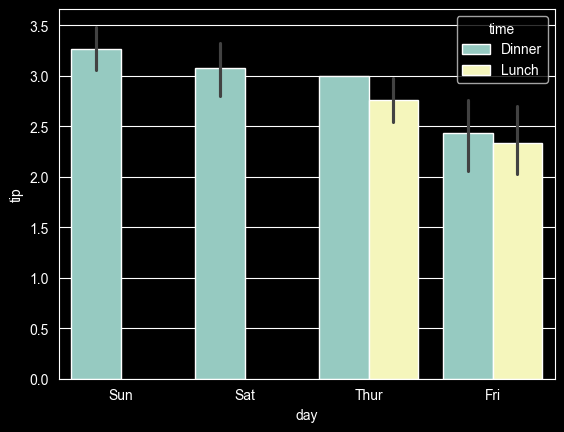

In [97]:
sns.barplot(df, x='day', y='tip', hue='time')

## Pergunta Analítica (Parte 4):

Para reter os funcionários é possível escalá-los em horários de maior gorjeta. Pelo que é possível verificar a partir das análises os dias com maiores gorjetas são no final de semana e no jantar. Pelas análises parece que clientes fumantes e não fumantes dão gorjetas bastante semelhantes, assim como clientes homens e mulheres dão valores semelhantes em gorjetas. Um padrão que parece um pouco mais lucrativo é que há gorjetas absolutas maiores no período noturno, talvez por que nesse período o valor total das contas sejam maiores.